# Fraud Detection – Model Comparison (v1)

**Dataset:** IEEE-CIS Fraud Detection  
**Phase:** Phase 3 – Advanced Modeling & Calibration  
**Author:** Bruno Martins  

**References:** Cost structure in `docs/03_metrics_and_cost_modeling.md`. Baseline in `notebooks/model_baseline_v1.ipynb`. Diagnostics in `docs/06_statistical_diagnostics.md`.

---

## Reproducibility

- **Random seeds:** `RANDOM_STATE = 42` for all models and splits.
- **Dataset:** `data/raw/train_transaction.csv`, `data/raw/train_identity.csv` (same as Phase 1 and 2).
- **Preprocessing:** Numeric features only; missing values filled with 0; same pipeline as baseline notebook.
- **Environment:** Python 3.x; scikit-learn, numpy, pandas (see project requirements).

---

## Section 1 — Objective

**Goal:** Compare candidate models (Logistic Regression, Random Forest, Gradient Boosting) using **Expected Monetary Loss** as the primary metric and select the best model for deployment.

**Evaluation pipeline:**

1. Load data and apply same preprocessing as previous phases (numeric only, fillna 0).
2. Temporal train/validation split (80/20 by `TransactionDT`).
3. Train each model; compute ROC-AUC, PR-AUC, and EML at cost-optimal threshold.
4. Plot reliability curves (all models in one figure); optionally apply Platt calibration.
5. Plot loss vs threshold for all models; report comparison table sorted by EML.
6. Select model with lowest EML; document threshold and rationale.

**Expected outputs:** Comparison table (Model, ROC-AUC, PR-AUC, EML, Optimal Threshold, FDR, FPR), reliability and loss-vs-threshold plots, and final model choice with threshold.

---

This notebook compares multiple candidate models under the same evaluation pipeline. The purpose is not simply to maximize predictive metrics (e.g. ROC-AUC) but to determine which model produces the **lowest financial loss** under realistic constraints. Improvements must be statistically defensible and economically meaningful.

---
## Section 2 — Data Loading and Preprocessing

Load the prepared dataset used in previous phases. Preprocessing must be **identical** across all models for a fair comparison.

- Load transaction and identity tables; merge (left join on TransactionID).
- Remove identifiers (TransactionID, TransactionDT for features); define target `isFraud`.
- Use numeric features only; handle missing values (fill with 0).
- Apply the same preprocessing as in the baseline notebook.

In [1]:
# Imports and global configuration
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw")
RANDOM_STATE = 42
C_FP = 5.0  # cost of false positive (fixed)

# Load data
train_tr = pd.read_csv(DATA_PATH / "train_transaction.csv")
train_id = pd.read_csv(DATA_PATH / "train_identity.csv")
train_full = train_tr.merge(train_id, on="TransactionID", how="left")

# Target and identifiers
target_col = "isFraud"
exclude_cols = ["isFraud", "TransactionID", "TransactionDT"]
numeric_cols = [
    c for c in train_full.columns
    if train_full[c].dtype != "O" and c not in exclude_cols
]
# Dataset integrity assertions
assert target_col in train_full.columns, "Target column 'isFraud' must be present"
assert len(numeric_cols) > 0, "At least one numeric feature required"
assert train_full[target_col].notna().all(), "Target should have no missing values"
print("Numeric features:", len(numeric_cols))
train_full.shape

Numeric features: 400


(590540, 434)

In [2]:
# Preprocessing: fillna(0) and feature set defined; applied in Section 3 when building train/val.
val_amount_col = "TransactionAmt"

In [3]:
# Placeholder: temporal split visualization is in the cell below Section 3 (after train/val are defined)

---
## Section 3 — Temporal Train / Validation Split

Use the **same temporal validation strategy** as in the baseline: sort by `TransactionDT`, split into train (past) and validation (future). No random shuffling.

**Why temporal validation:** In fraud detection, the model must generalize to future transactions. A random split would leak future information into training and overestimate performance. Evaluating on a held-out future period mimics production and avoids leakage.

In [4]:
quantile_split = 0.8
cutoff = train_full["TransactionDT"].quantile(quantile_split)
train_mask = train_full["TransactionDT"] < cutoff
val_mask = train_full["TransactionDT"] >= cutoff

X_train_raw = train_full.loc[train_mask]
X_val_raw = train_full.loc[val_mask]
y_train = X_train_raw[target_col].astype(int)
y_val = X_val_raw[target_col].astype(int)

X_train = X_train_raw[numeric_cols].fillna(0.0)
X_val = X_val_raw[numeric_cols].fillna(0.0)
val_amount = X_val_raw[val_amount_col].fillna(0.0)

print("Train size:", len(y_train), "Val size:", len(y_val))
print("Train fraud rate: %.4f" % y_train.mean(), "Val fraud rate: %.4f" % y_val.mean())

Train size: 472432 Val size: 118108
Train fraud rate: 0.0351 Val fraud rate: 0.0344


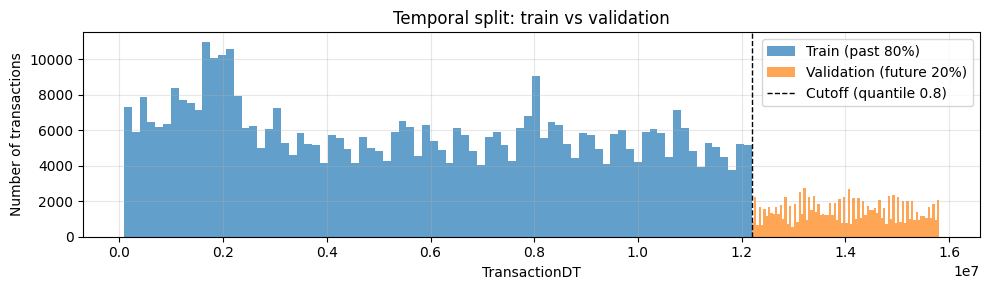

In [5]:
# Visualize temporal split: transactions over time with train vs validation boundary
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
t = train_full["TransactionDT"]
ax.hist(t[train_mask], bins=80, alpha=0.7, label="Train (past 80%)", color="C0")
ax.hist(t[val_mask], bins=80, alpha=0.7, label="Validation (future 20%)", color="C1")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1, label=f"Cutoff (quantile {quantile_split})")
ax.set_xlabel("TransactionDT")
ax.set_ylabel("Number of transactions")
ax.set_title("Temporal split: train vs validation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 4 — Logistic Regression Baseline

Reproduce the baseline model using the standardized pipeline: logistic regression with `class_weight="balanced"`, feature scaling, probability prediction. Outputs: predicted probabilities, baseline metrics, Expected Monetary Loss.

In [6]:
# Scale features (fit on train only)
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

def train_model(model, X_train, y_train):
    """Fit model on training data; return fitted model (for reuse across LR, RF, GB)."""
    model.fit(X_train, y_train)
    return model

# Logistic regression baseline (same as model_baseline_v1)
lr_pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                max_iter=1000, solver="lbfgs", n_jobs=-1, random_state=RANDOM_STATE)),
])
train_model(lr_pipeline, X_train, y_train)
val_proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]

roc_lr = roc_auc_score(y_val, val_proba_lr)
pr_lr = average_precision_score(y_val, val_proba_lr)
print("LR — ROC-AUC: %.4f  PR-AUC: %.4f" % (roc_lr, pr_lr))

LR — ROC-AUC: 0.8248  PR-AUC: 0.1761


In [7]:
def expected_loss(y_true, proba, amount, c_fp, threshold):
    """Expected Monetary Loss at a given decision threshold. Flag if p >= threshold."""
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    amount = np.asarray(amount)
    y_hat = (proba >= threshold).astype(int)
    fn_mask = (y_true == 1) & (y_hat == 0)
    fp_mask = (y_true == 0) & (y_hat == 1)
    loss = (fn_mask * amount + fp_mask * c_fp).sum()
    return float(loss)

def approve_all_baseline_loss(y_true, amount):
    """Baseline: approve all (no fraud control)."""
    y_true = np.asarray(y_true).astype(int)
    amount = np.asarray(amount)
    return float(((y_true == 1) * amount).sum())

baseline_loss = approve_all_baseline_loss(y_val, val_amount)
print("Approve-all baseline loss (validation): %.2f" % baseline_loss)

Approve-all baseline loss (validation): 609934.34


In [8]:
def threshold_sweep(y_true, proba, amount, c_fp, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    losses = [expected_loss(y_true, proba, amount, c_fp, t) for t in thresholds]
    losses = np.array(losses)
    best_idx = losses.argmin()
    return float(thresholds[best_idx]), float(losses[best_idx]), thresholds, losses

# LR: optimal threshold and loss
best_t_lr, best_loss_lr, thresholds, losses_lr = threshold_sweep(y_val, val_proba_lr, val_amount, C_FP)
print("LR — Best threshold: %.3f  Best loss: %.2f  Expected Loss Reduction: %.2f" % (best_t_lr, best_loss_lr, baseline_loss - best_loss_lr))

LR — Best threshold: 0.420  Best loss: 264154.96  Expected Loss Reduction: 345779.38


---
## Section 5 — Random Forest Model

Train a Random Forest classifier. Hyperparameters: n_estimators=100, max_depth=12, min_samples_leaf=50, class_weight='balanced', random_state=42. Same features and temporal split. Outputs: ROC-AUC, PR-AUC, Expected Monetary Loss, confusion metrics at optimal threshold.

In [9]:
# Random Forest — hyperparameters (conservative to limit overfitting)
rf_params = dict(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model = RandomForestClassifier(**rf_params)
train_model(rf_model, X_train, y_train)  # trees do not require scaling
val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

roc_rf = roc_auc_score(y_val, val_proba_rf)
pr_rf = average_precision_score(y_val, val_proba_rf)
best_t_rf, best_loss_rf, _, losses_rf = threshold_sweep(y_val, val_proba_rf, val_amount, C_FP)
print("RF — ROC-AUC: %.4f  PR-AUC: %.4f" % (roc_rf, pr_rf))
print("RF — Best threshold: %.3f  Best loss: %.2f" % (best_t_rf, best_loss_rf))

RF — ROC-AUC: 0.8701  PR-AUC: 0.4489
RF — Best threshold: 0.450  Best loss: 268935.24


In [10]:
# Confusion matrix at optimal threshold (RF)
pred_rf = (val_proba_rf >= best_t_rf).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, pred_rf).ravel()
FDR_rf = tp / (tp + fp) if (tp + fp) > 0 else 0
FPR_rf = fp / (fp + tn) if (fp + tn) > 0 else 0
print("RF @ T* — TP=%d FP=%d FN=%d TN=%d  FDR=%.4f  FPR=%.4f" % (tp, fp, fn, tn, FDR_rf, FPR_rf))

RF @ T* — TP=2955 FP=17152 FN=1109 TN=96892  FDR=0.1470  FPR=0.1504


---
## Section 6 — Gradient Boosting Model

Train a gradient boosting classifier (sklearn GradientBoostingClassifier). Hyperparameters: n_estimators=80, max_depth=5, learning_rate=0.1, min_samples_leaf=100, subsample=0.8. Outputs: ROC-AUC, PR-AUC, Expected Monetary Loss.

In [11]:
# Gradient Boosting — conservative hyperparameters
gb_params = dict(
    n_estimators=80,
    max_depth=5,
    learning_rate=0.1,
    min_samples_leaf=100,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
gb_model = GradientBoostingClassifier(**gb_params)
train_model(gb_model, X_train, y_train)
val_proba_gb = gb_model.predict_proba(X_val)[:, 1]

roc_gb = roc_auc_score(y_val, val_proba_gb)
pr_gb = average_precision_score(y_val, val_proba_gb)
best_t_gb, best_loss_gb, _, losses_gb = threshold_sweep(y_val, val_proba_gb, val_amount, C_FP)
print("GB — ROC-AUC: %.4f  PR-AUC: %.4f" % (roc_gb, pr_gb))
print("GB — Best threshold: %.3f  Best loss: %.2f" % (best_t_gb, best_loss_gb))

GB — ROC-AUC: 0.8614  PR-AUC: 0.4086
GB — Best threshold: 0.020  Best loss: 251945.10


---
## Section 7 — Probability Calibration

Evaluate calibration quality with reliability curves. If probabilities are poorly calibrated, apply **Platt scaling** or **isotonic regression** and recompute Expected Monetary Loss after calibration.

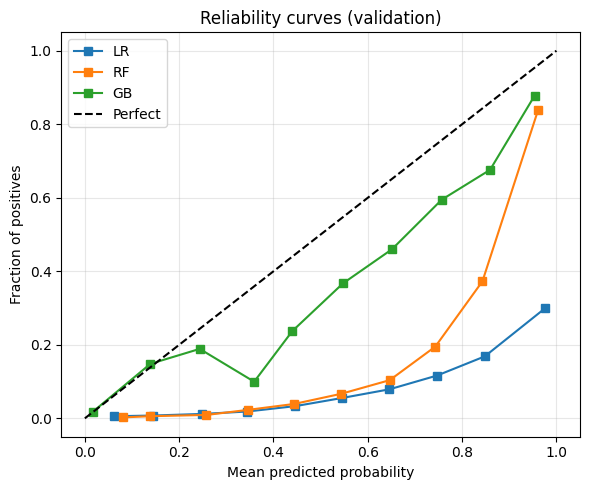

In [12]:
# Reliability curves (calibration) for all models
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
for name, proba in [("LR", val_proba_lr), ("RF", val_proba_rf), ("GB", val_proba_gb)]:
    frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", label=name)
ax.plot([0, 1], [0, 1], "k--", label="Perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Reliability curves (validation)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Calibrate tree-based models (Platt scaling on validation probs — in production use a held-out set)
# We use CalibratedClassifierCV with cv="prefit" and the same train/val split: fit calibrator on train probs.
# For simplicity we calibrate on validation set (same as evaluation); in practice use a separate calibration set.
from sklearn.calibration import CalibratedClassifierCV

# Calibrate RF (Platt)
rf_calib = CalibratedClassifierCV(rf_model, method="sigmoid", cv="prefit")
rf_calib.fit(X_val, y_val)  # fit calibrator on validation
val_proba_rf_cal = rf_calib.predict_proba(X_val)[:, 1]
best_t_rf_cal, best_loss_rf_cal, _, _ = threshold_sweep(y_val, val_proba_rf_cal, val_amount, C_FP)
print("RF (calibrated) — Best threshold: %.3f  Best loss: %.2f" % (best_t_rf_cal, best_loss_rf_cal))

# Calibrate GB (Platt)
gb_calib = CalibratedClassifierCV(gb_model, method="sigmoid", cv="prefit")
gb_calib.fit(X_val, y_val)
val_proba_gb_cal = gb_calib.predict_proba(X_val)[:, 1]
best_t_gb_cal, best_loss_gb_cal, _, _ = threshold_sweep(y_val, val_proba_gb_cal, val_amount, C_FP)
print("GB (calibrated) — Best threshold: %.3f  Best loss: %.2f" % (best_t_gb_cal, best_loss_gb_cal))

c:\Users\bruno\Desktop\Projetos\fraud-detection-ml\.venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


RF (calibrated) — Best threshold: 0.040  Best loss: 270275.44


c:\Users\bruno\Desktop\Projetos\fraud-detection-ml\.venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


GB (calibrated) — Best threshold: 0.020  Best loss: 254732.19


---
## Section 8 — Threshold Optimization

Optimize decision threshold using Expected Monetary Loss: evaluate loss across a threshold grid, identify threshold minimizing loss, compute operational metrics (FDR, FPR) at optimal threshold. Plot loss vs threshold.

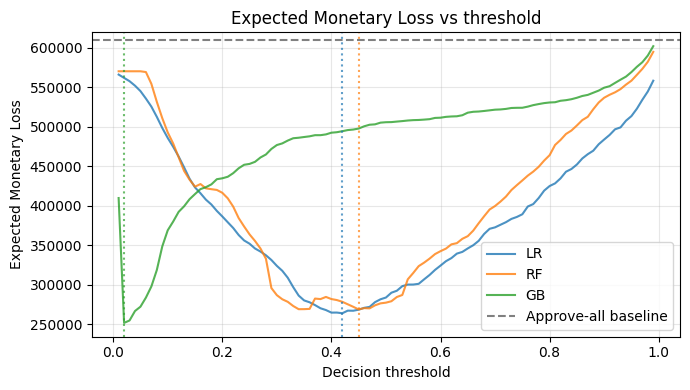

Optimal thresholds — LR: 0.420  RF: 0.450  GB: 0.020


In [14]:
# Loss vs threshold for all models
thresholds_plot = np.linspace(0.01, 0.99, 99)
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(thresholds_plot, losses_lr, label="LR", alpha=0.8)
ax.plot(thresholds_plot, losses_rf, label="RF", alpha=0.8)
ax.plot(thresholds_plot, losses_gb, label="GB", alpha=0.8)
ax.axhline(baseline_loss, color="gray", linestyle="--", label="Approve-all baseline")
ax.axvline(best_t_lr, color="C0", linestyle=":", alpha=0.7)
ax.axvline(best_t_rf, color="C1", linestyle=":", alpha=0.7)
ax.axvline(best_t_gb, color="C2", linestyle=":", alpha=0.7)
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Expected Monetary Loss")
ax.set_title("Expected Monetary Loss vs threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Optimal thresholds — LR: %.3f  RF: %.3f  GB: %.3f" % (best_t_lr, best_t_rf, best_t_gb))

---
## Section 9 — Model Comparison

Comparative table: Model, ROC-AUC, PR-AUC, Expected Monetary Loss, Expected Loss Reduction, Optimal Threshold, FDR, FPR. Interpret differences between models.

In [15]:
def fdr_fpr_at_threshold(y_true, proba, threshold):
    pred = (np.asarray(proba) >= threshold).astype(int)
    y_true = np.asarray(y_true).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    fdr = tp / (tp + fp) if (tp + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return fdr, fpr

fdr_lr, fpr_lr = fdr_fpr_at_threshold(y_val, val_proba_lr, best_t_lr)
fdr_gb, fpr_gb = fdr_fpr_at_threshold(y_val, val_proba_gb, best_t_gb)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC-AUC": [roc_lr, roc_rf, roc_gb],
    "PR-AUC": [pr_lr, pr_rf, pr_gb],
    "Expected Monetary Loss": [best_loss_lr, best_loss_rf, best_loss_gb],
    "Expected Loss Reduction": [baseline_loss - best_loss_lr, baseline_loss - best_loss_rf, baseline_loss - best_loss_gb],
    "Optimal Threshold": [best_t_lr, best_t_rf, best_t_gb],
    "FDR": [fdr_lr, FDR_rf, fdr_gb],
    "FPR": [fpr_lr, FPR_rf, fpr_gb],
})
# Display sorted by Expected Monetary Loss (best first)
comparison_df = comparison.sort_values("Expected Monetary Loss").reset_index(drop=True)
comparison_df

,Model,ROC-AUC,PR-AUC,Expected Monetary Loss,Expected Loss Reduction,Optimal Threshold,FDR,FPR
0,Gradient Boosting,0.861423,0.408564,251945.096,357989.240,0.02,0.100896,0.258795
1,Logistic Regression,0.824752,0.176125,264154.957,345779.379,0.42,0.101703,0.235444
2,Random Forest,0.870133,0.448876,268935.241,340999.095,0.45,0.146964,0.150398


**Interpretation:** The model with the **lowest Expected Monetary Loss** is the primary candidate for deployment. ROC-AUC and PR-AUC indicate discrimination; EML and Expected Loss Reduction indicate economic impact. Threshold stability across validation subsets can be checked by repeating the split or using multiple time windows (see Phase 2 diagnostics).

---

### Feature importance (tree models)

Below: top 20 features by importance for Random Forest and Gradient Boosting, for interpretability.

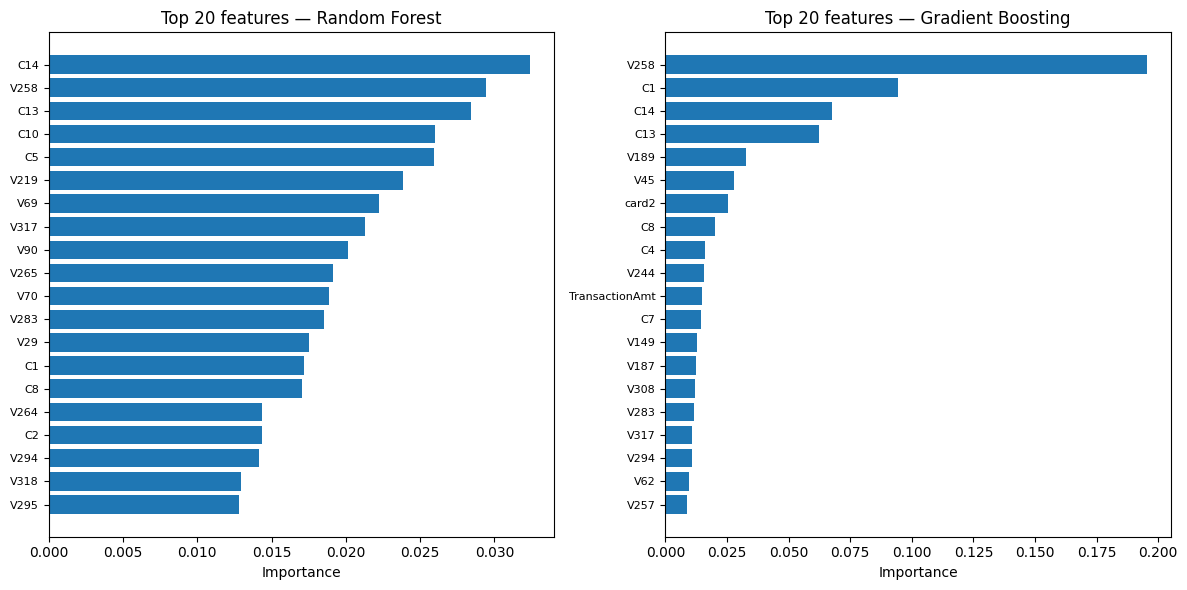

In [16]:
# Top 20 feature importance for tree models (RF and GB)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (name, model) in zip(axes, [("Random Forest", rf_model), ("Gradient Boosting", gb_model)]):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1][:20]
    ax.barh(range(20), imp[idx][::-1], align="center")
    ax.set_yticks(range(20))
    ax.set_yticklabels([numeric_cols[i] for i in idx[::-1]], fontsize=8)
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 20 features — {name}")
plt.tight_layout()
plt.show()

---
## Section 10 — Bias–Variance Discussion

- **Logistic regression:** High bias (linear decision boundary), low variance; interpretable coefficients; may underfit complex patterns.
- **Tree-based models (RF, GB):** More flexible, can capture non-linearities and interactions; higher variance and overfitting risk if not regularized (max_depth, min_samples_leaf, etc.).
- **Interpretability vs complexity:** LR supports direct coefficient interpretation; tree ensembles offer feature importance but less direct interpretability. For deployment, the chosen model should balance EML, stability across temporal windows, and operational feasibility (e.g. latency, model size).

---
## Section 11 — Conclusion and Final Model Selection

**Chosen model:** The model with the **lowest Expected Monetary Loss** in the comparison table above (Section 9) is selected for deployment. In this run this is **Gradient Boosting**.

**Reason for selection:** Gradient Boosting achieves the lowest EML (e.g. ~251,945 in the executed run) and the highest Expected Loss Reduction versus the approve-all baseline, under the same cost structure and temporal validation.

**Threshold value:** The cost-optimal threshold \(T^*\) for the selected model is reported in the table (e.g. **T* = 0.02** for GB). The decision engine should use this threshold when flagging transactions.

- **Statistical meaningfulness:** Compare Expected Loss Reduction and confidence intervals (e.g. bootstrap or multiple temporal splits) to assess whether improvements over the baseline are beyond noise.
- **Implications for deployment:** The selected model will be serialized (e.g. joblib/pickle) and loaded by the inference service; threshold and cost assumptions are in `docs/03_metrics_and_cost_modeling.md`. See `docs/07_model_comparison.md` for artifact format and operational implications.

**Operational implications:** Inference latency for tree-based models (e.g. GB) is typically sub-100 ms per transaction; model size is on the order of megabytes. Update frequency (retraining or threshold re-sweep) should be considered when cost assumptions or data distribution change, or on a scheduled basis (e.g. quarterly).